# fio — Per-Config Box Plots & Run Statistics

Each `(bs, numjobs)` configuration was run multiple times.  
This notebook shows the per-run spread (box + individual-point overlay) and a  
summary statistics table for **bandwidth**, **IOPS**, and **completion latency**.

- Fixed: `iodepth=16`
- Axes: `bs` ∈ {4k, 16k, 1m, 2m, 4m} × `numjobs` ∈ {4, 8, 16, 32, 64}

In [1]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "16k", "1m", "2m", "4m"]
NJ_ORDER = [4, 8, 16, 32, 64]

## Seq Read

In [2]:
def bs_to_bytes(bs: str) -> int:
    bs = bs.lower()
    if bs.endswith("k"):
        return int(bs[:-1]) * 1024
    if bs.endswith("m"):
        return int(bs[:-1]) * 1024 ** 2
    return int(bs)


def parse_file(fpath: Path) -> dict:
    m = re.search(r"fio_\w+_bs(\w+?)_nj(\d+)_iod(\d+)_", fpath.name)
    bs, nj, iod = m.group(1), int(m.group(2)), int(m.group(3))

    with open(fpath) as f:
        d = json.load(f)

    job = d["jobs"][0]
    io  = job["read"] if job["read"]["io_bytes"] > 0 else job["write"]
    clat = io["clat_ns"]
    lat  = io["lat_ns"]
    cp   = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        bs             = bs,
        numjobs        = nj,
        iodepth        = iod,
        bw_GiBs        = io["bw_bytes"] / 1024 ** 3,
        iops           = io["iops"],
        lat_mean_ms    = ms(lat["mean"]),
        clat_mean_ms   = ms(clat["mean"]),
        clat_p50_ms    = ms(cp["50.000000"]),
        clat_p90_ms    = ms(cp["90.000000"]),
        clat_p99_ms    = ms(cp["99.000000"]),
        clat_p99_9_ms  = ms(cp["99.900000"]),
        clat_p99_99_ms = ms(cp["99.990000"]),
    )

### Load all seq_read runs (no averaging)

In [3]:
sr_files = [f for f in sorted(RESULTS_DIR.glob("fio_seq_read_*.json")) if f.stat().st_size > 0]
sr_raw = pd.DataFrame([parse_file(f) for f in sr_files])

sr_raw["bs"]       = pd.Categorical(sr_raw["bs"],                  categories=BS_ORDER, ordered=True)
sr_raw["numjobs"]  = pd.Categorical(sr_raw["numjobs"].astype(int), categories=NJ_ORDER, ordered=True)
sr_raw["bs_bytes"] = sr_raw["bs"].apply(bs_to_bytes)
sr_raw = sr_raw.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

n_total = sum(1 for _ in RESULTS_DIR.glob("fio_seq_read_*.json"))
print(f"Loaded {len(sr_files)} seq_read JSON files ({n_total - len(sr_files)} empty skipped)")
sr_raw.head(10)

Loaded 284 seq_read JSON files (0 empty skipped)


,bs,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,0.696877,182682.121965,0.350009,0.346000,0.358400,0.501760,0.602112,0.905216,9.895936,4096
1,4k,4,16,0.709672,186036.282729,0.343653,0.339806,0.354304,0.493568,0.593920,1.011712,9.371648,4096
2,4k,4,16,0.704567,184697.888369,0.345995,0.342015,0.354304,0.493568,0.593920,1.044480,10.158080,4096
3,4k,4,16,0.715634,187599.056682,0.340781,0.336751,0.350208,0.489472,0.593920,0.929792,10.158080,4096
4,4k,4,16,0.700523,183638.006033,0.348028,0.344059,0.358400,0.497664,0.602112,1.286144,10.289152,4096
5,4k,4,16,0.697051,182727.754537,0.349860,0.345941,0.358400,0.497664,0.602112,0.954368,10.027008,4096
6,4k,4,16,0.702487,184152.797453,0.347200,0.343332,0.358400,0.497664,0.593920,0.913408,10.027008,4096
7,4k,4,16,0.708060,185613.639773,0.344358,0.340358,0.354304,0.493568,0.593920,1.003520,10.420224,4096
8,4k,4,16,0.695374,182288.195197,0.350648,0.346687,0.358400,0.497664,0.602112,0.987136,10.158080,4096
9,4k,4,16,0.705821,185026.716221,0.345450,0.341621,0.354304,0.493568,0.593920,1.003520,10.027008,4096


### Run counts per configuration

In [4]:
run_counts = (
    sr_raw.groupby(["bs", "numjobs"], observed=True)
    .size()
    .unstack("numjobs")
    .reindex(BS_ORDER)
)
print("Runs per (bs, numjobs) configuration:")
display(run_counts)

Runs per (bs, numjobs) configuration:


numjobs,4,8,16,32,64
bs,,,,,
4k,12,12,12,12,12
16k,12,12,12,12,12
1m,12,12,12,12,12
2m,11,11,11,11,10
4m,10,10,10,10,10


### Summary statistics per configuration

In [5]:
summary = sr_raw.groupby(["bs", "numjobs"], observed=True).agg(
    n             = ("bw_GiBs",      "count"),
    bw_median     = ("bw_GiBs",      "median"),
    bw_std        = ("bw_GiBs",      "std"),
    bw_cv_pct     = ("bw_GiBs",      lambda x: x.std() / x.mean() * 100),
    bw_min        = ("bw_GiBs",      "min"),
    bw_max        = ("bw_GiBs",      "max"),
    iops_mean     = ("iops",         "mean"),
    iops_std      = ("iops",         "std"),
    clat_mean     = ("clat_mean_ms", "mean"),
    clat_std      = ("clat_mean_ms", "std"),
    clat_p99_mean = ("clat_p99_ms",  "mean"),
    clat_p99_std  = ("clat_p99_ms",  "std"),
).reset_index()
summary["bs"] = pd.Categorical(summary["bs"], categories=BS_ORDER, ordered=True)
summary = summary.sort_values(["bs", "numjobs"]).reset_index(drop=True)
display(summary.round(3))

,bs,numjobs,n,bw_median,bw_std,bw_cv_pct,bw_min,bw_max,iops_mean,iops_std,clat_mean,clat_std,clat_p99_mean,clat_p99_std
0,4k,4,12,0.702,0.006,0.858,0.695,0.716,184274.540,1580.717,0.343,0.003,0.597,0.004
1,4k,8,12,1.393,0.009,0.623,1.385,1.414,366068.915,2281.399,0.345,0.002,0.602,0.003
2,4k,16,12,2.679,0.190,7.312,2.217,2.730,680194.173,49734.498,0.374,0.031,0.748,0.100
3,4k,32,12,2.134,0.452,20.525,1.642,2.908,577301.132,118489.556,0.916,0.182,1.712,0.159
4,4k,64,12,3.172,0.198,6.263,2.878,3.474,828685.075,51901.859,1.235,0.077,2.589,0.214
5,16k,4,12,2.629,0.317,12.201,1.825,3.015,170263.728,20774.371,0.377,0.056,0.797,0.116
6,16k,8,12,3.330,0.400,12.431,2.388,3.914,211080.535,26240.430,0.611,0.087,1.246,0.151
7,16k,16,12,3.472,0.376,10.998,2.918,4.190,224307.684,24669.759,1.148,0.125,2.034,0.104
8,16k,32,12,3.666,0.328,9.170,2.933,4.104,234545.704,21508.788,2.194,0.212,3.746,0.574
9,16k,64,12,3.791,0.213,5.531,3.519,4.229,252097.452,13942.767,4.065,0.223,6.521,0.566


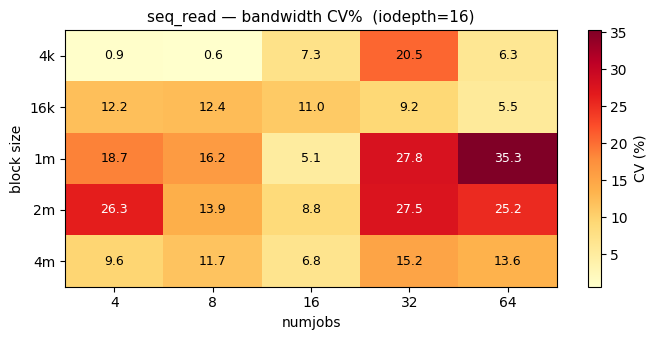

In [6]:
sr_cv_pivot = (
    summary.pivot(index="bs", columns="numjobs", values="bw_cv_pct")
    .reindex(BS_ORDER)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(sr_cv_pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="CV (%)")

ax.set_xticks(range(len(NJ_ORDER)))
ax.set_xticklabels(NJ_ORDER)
ax.set_yticks(range(len(BS_ORDER)))
ax.set_yticklabels(BS_ORDER)
ax.set_xlabel("numjobs")
ax.set_ylabel("block size")
ax.set_title("seq_read — bandwidth CV%  (iodepth=16)", fontsize=11)

valid = sr_cv_pivot.values[~np.isnan(sr_cv_pivot.values)]
for i, bs in enumerate(BS_ORDER):
    for j, nj in enumerate(NJ_ORDER):
        val = sr_cv_pivot.loc[bs, nj]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9,
                    color="black" if val < valid.max() * 0.6 else "white")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "seqread_cv_pct_heatmap.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [7]:
print("seq_read — bandwidth CV% per (bs, numjobs)")
display(sr_cv_pivot.round(1))

seq_read — bandwidth CV% per (bs, numjobs)


numjobs,4,8,16,32,64
bs,,,,,
4k,0.9,0.6,7.3,20.5,6.3
16k,12.2,12.4,11.0,9.2,5.5
1m,18.7,16.2,5.1,27.8,35.3
2m,26.3,13.9,8.8,27.5,25.2
4m,9.6,11.7,6.8,15.2,13.6


### Box plots — Bandwidth, IOPS, Mean latency, P99 latency

One figure per metric. Each figure has five subplots (one per block size);  
x-axis = `numjobs`, each dot = one run, box spans IQR, whiskers reach min/max.

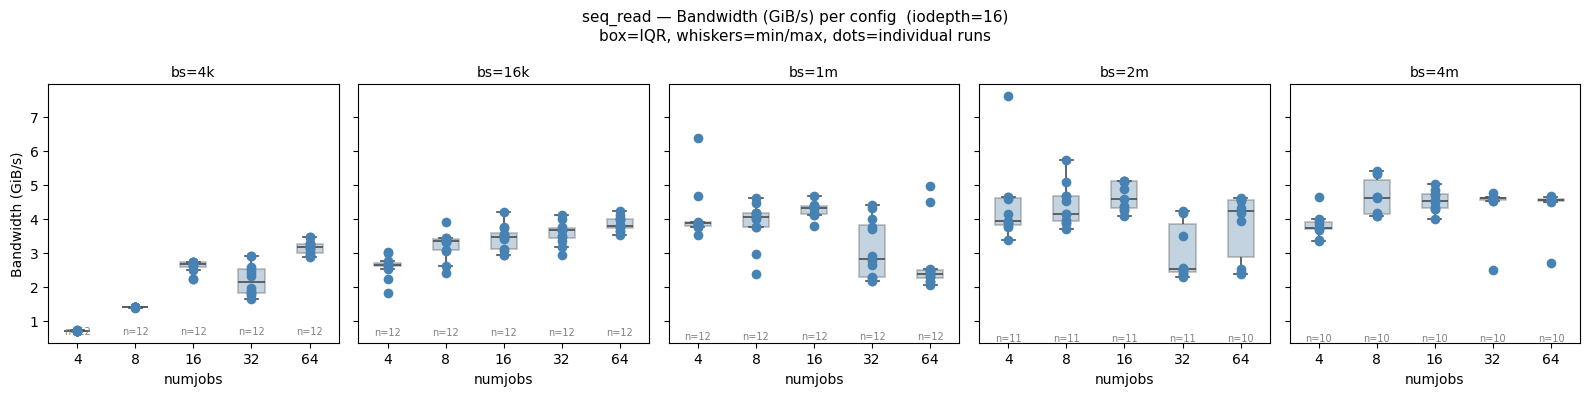

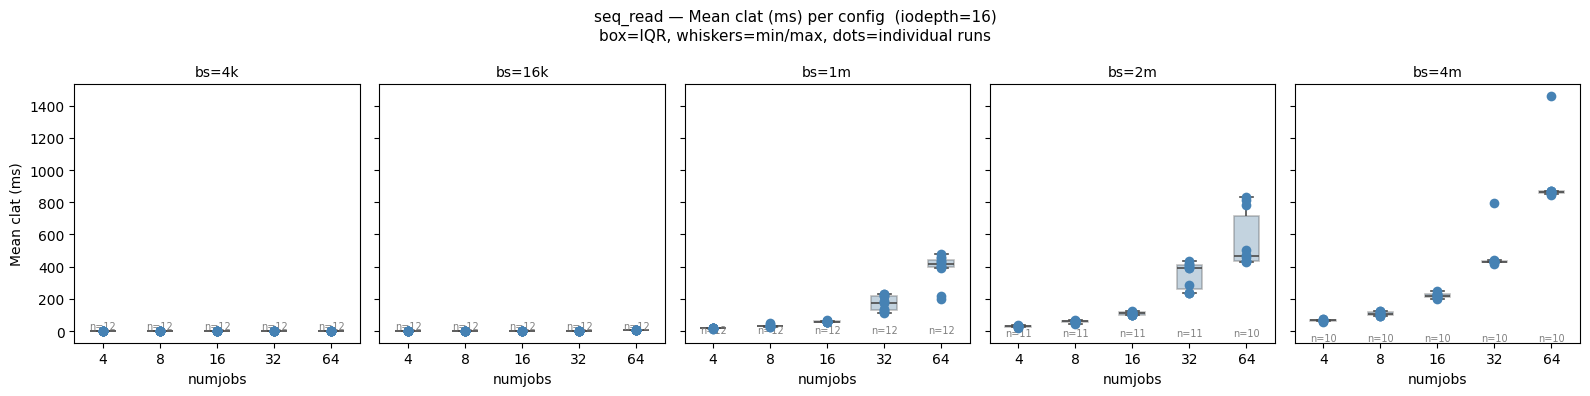

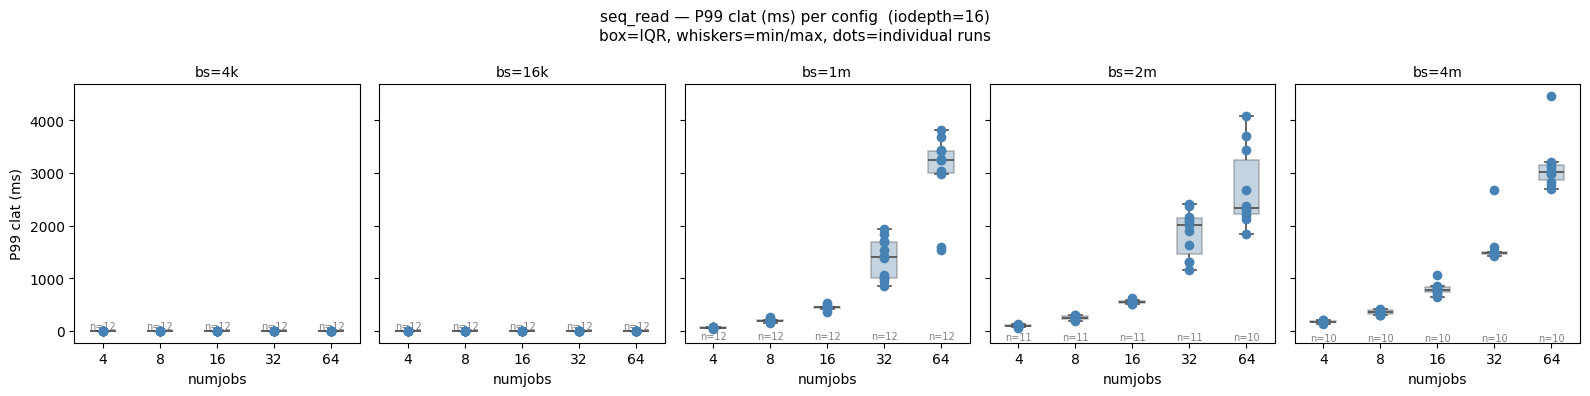

In [8]:
bp_metrics = [
    ("bw_GiBs",      "Bandwidth (GiB/s)"),
    ("clat_mean_ms", "Mean clat (ms)"),
    ("clat_p99_ms",  "P99 clat (ms)"),
]

for metric, ylabel in bp_metrics:
    fig, axes = plt.subplots(1, len(BS_ORDER), figsize=(16, 4), sharey=True)
    fig.suptitle(
        f"seq_read — {ylabel} per config  (iodepth=16)\n"
        "box=IQR, whiskers=min/max, dots=individual runs",
        fontsize=11,
    )

    for ax, bs in zip(axes, BS_ORDER):
        sub = sr_raw[sr_raw["bs"] == bs]

        sns.boxplot(
            data=sub, x="numjobs", y=metric, ax=ax,
            color="steelblue", width=0.45, fliersize=0, linewidth=1.2,
            boxprops=dict(alpha=0.35),
        )
        sns.stripplot(
            data=sub, x="numjobs", y=metric, ax=ax,
            color="steelblue", size=7, jitter=False, zorder=5,
        )

        # n= annotation below each group
        ymin = ax.get_ylim()[0]
        for i, nj in enumerate(NJ_ORDER):
            n = len(sub[sub["numjobs"] == nj])
            if n > 0:
                ax.text(i, ymin, f"n={n}", ha="center", va="bottom",
                        fontsize=7, color="gray")

        ax.set_title(f"bs={bs}", fontsize=10)
        ax.set_xlabel("numjobs")
        ax.set_ylabel(ylabel if ax is axes[0] else "")
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"boxplot_seqread_{metric}.pdf", bbox_inches="tight", dpi=150)
    plt.show()

## Rand Write

### Load all rand_write runs (no averaging)

In [9]:
rw_files = [f for f in sorted(RESULTS_DIR.glob("fio_rand_write_*.json")) if f.stat().st_size > 0]
rw_raw = pd.DataFrame([parse_file(f) for f in rw_files])

rw_raw["bs"]       = pd.Categorical(rw_raw["bs"],                  categories=BS_ORDER, ordered=True)
rw_raw["numjobs"]  = pd.Categorical(rw_raw["numjobs"].astype(int), categories=NJ_ORDER, ordered=True)
rw_raw["bs_bytes"] = rw_raw["bs"].apply(bs_to_bytes)
rw_raw = rw_raw.sort_values(["bs_bytes", "numjobs"]).reset_index(drop=True)

n_total = sum(1 for _ in RESULTS_DIR.glob("fio_rand_write_*.json"))
print(f"Loaded {len(rw_files)} rand_write JSON files ({n_total - len(rw_files)} empty skipped)")
rw_raw.head(10)

Loaded 250 rand_write JSON files (0 empty skipped)


,bs,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,clat_mean_ms,clat_p50_ms,clat_p90_ms,clat_p99_ms,clat_p99_9_ms,clat_p99_99_ms,bs_bytes
0,4k,4,16,2.543760,666831.327911,0.095653,0.092305,0.083456,0.107008,0.128512,1.662976,3.588096,4096
1,4k,4,16,2.504445,656525.140410,0.097166,0.093823,0.084480,0.108032,0.138240,1.744896,4.751360,4096
2,4k,4,16,2.460161,644916.384727,0.098889,0.095557,0.083456,0.108032,0.358400,1.761280,4.751360,4096
3,4k,4,16,2.432111,637563.414553,0.100006,0.096625,0.084480,0.109056,0.292864,1.761280,4.751360,4096
4,4k,4,16,2.490482,652864.787840,0.097717,0.094409,0.082432,0.107008,0.261120,1.761280,4.882432,4096
5,4k,4,16,2.426801,636171.410953,0.100279,0.096841,0.084480,0.109056,0.264192,1.744896,4.685824,4096
6,4k,4,16,2.474536,648684.660511,0.098337,0.095015,0.083456,0.108032,0.259072,1.744896,4.751360,4096
7,4k,4,16,2.446329,641290.456985,0.099479,0.096110,0.084480,0.109056,0.354304,1.777664,4.751360,4096
8,4k,4,16,2.417450,633720.059331,0.100673,0.097284,0.085504,0.109056,0.333824,1.761280,4.751360,4096
9,4k,4,16,2.505255,656737.535826,0.097099,0.093764,0.083456,0.108032,0.129536,1.744896,4.751360,4096


### Run counts per configuration

In [10]:
rw_run_counts = (
    rw_raw.groupby(["bs", "numjobs"], observed=True)
    .size()
    .unstack("numjobs")
    .reindex(BS_ORDER)
)
print("Runs per (bs, numjobs) configuration:")
display(rw_run_counts)

Runs per (bs, numjobs) configuration:


numjobs,4,8,16,32,64
bs,,,,,
4k,10,10,10,10,10
16k,10,10,10,10,10
1m,10,10,10,10,10
2m,10,10,10,10,10
4m,10,10,10,10,10


### Run-to-run variability (summary statistics per configuration)

In [11]:
rw_summary = rw_raw.groupby(["bs", "numjobs"], observed=True).agg(
    n             = ("bw_GiBs",      "count"),
    bw_mean       = ("bw_GiBs",      "mean"),
    bw_std        = ("bw_GiBs",      "std"),
    bw_cv_pct     = ("bw_GiBs",      lambda x: x.std() / x.mean() * 100),
    bw_min        = ("bw_GiBs",      "min"),
    bw_max        = ("bw_GiBs",      "max"),
    iops_mean     = ("iops",         "mean"),
    iops_std      = ("iops",         "std"),
    clat_mean     = ("clat_mean_ms", "mean"),
    clat_std      = ("clat_mean_ms", "std"),
    clat_p99_mean = ("clat_p99_ms",  "mean"),
    clat_p99_std  = ("clat_p99_ms",  "std"),
).reset_index()
rw_summary["bs"] = pd.Categorical(rw_summary["bs"], categories=BS_ORDER, ordered=True)
rw_summary = rw_summary.sort_values(["bs", "numjobs"]).reset_index(drop=True)
display(rw_summary.round(3))

,bs,numjobs,n,bw_mean,bw_std,bw_cv_pct,bw_min,bw_max,iops_mean,iops_std,clat_mean,clat_std,clat_p99_mean,clat_p99_std
0,4k,4,10,2.470,0.041,1.654,2.417,2.544,647530.518,10712.679,0.095,0.002,0.252,0.090
1,4k,8,10,4.725,0.042,0.884,4.674,4.816,1238516.191,10949.070,0.100,0.001,0.274,0.028
2,4k,16,10,6.802,0.151,2.214,6.521,7.069,1783051.645,39472.723,0.140,0.003,1.126,0.110
3,4k,32,10,6.813,0.391,5.745,5.938,7.116,1786087.035,102602.556,0.283,0.018,2.017,0.123
4,4k,64,10,5.834,0.674,11.562,4.974,7.164,1529265.742,176811.320,0.671,0.072,4.330,0.735
5,16k,4,10,7.778,0.109,1.403,7.567,7.939,509760.493,7150.227,0.121,0.002,0.270,0.063
6,16k,8,10,14.816,0.414,2.794,13.852,15.357,970977.433,27128.998,0.127,0.004,0.564,0.218
7,16k,16,10,16.000,1.615,10.094,11.650,17.104,1048587.899,105840.489,0.242,0.032,2.530,0.363
8,16k,32,10,16.106,0.365,2.268,15.659,16.795,1055513.283,23937.627,0.480,0.011,6.062,0.317
9,16k,64,10,16.676,0.360,2.158,16.211,17.317,1092887.003,23584.712,0.929,0.020,8.900,0.224


### Box plot — Bandwidth (GiB/s)

One subplot per block size; x-axis = `numjobs`, each dot = one run.

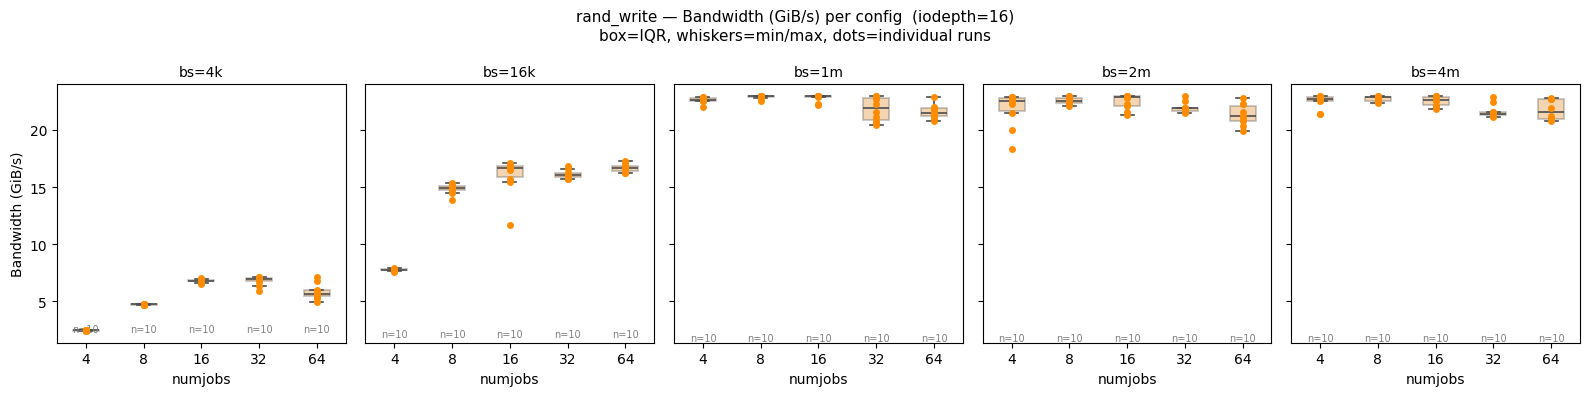

In [12]:
fig, axes = plt.subplots(1, len(BS_ORDER), figsize=(16, 4), sharey=True)
fig.suptitle(
    "rand_write — Bandwidth (GiB/s) per config  (iodepth=16)\n"
    "box=IQR, whiskers=min/max, dots=individual runs",
    fontsize=11,
)

for ax, bs in zip(axes, BS_ORDER):
    sub = rw_raw[rw_raw["bs"] == bs]

    sns.boxplot(
        data=sub, x="numjobs", y="bw_GiBs", ax=ax,
        color="darkorange", width=0.45, fliersize=0, linewidth=1.2,
        boxprops=dict(alpha=0.35),
    )
    sns.stripplot(
        data=sub, x="numjobs", y="bw_GiBs", ax=ax,
        color="darkorange", size=5, jitter=False, zorder=5,
    )

    ymin = ax.get_ylim()[0]
    for i, nj in enumerate(NJ_ORDER):
        n = len(sub[sub["numjobs"] == nj])
        if n > 0:
            ax.text(i, ymin, f"n={n}", ha="center", va="bottom",
                    fontsize=7, color="gray")

    ax.set_title(f"bs={bs}", fontsize=10)
    ax.set_xlabel("numjobs")
    ax.set_ylabel("Bandwidth (GiB/s)" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "boxplot_randwrite_bw_GiBs.pdf", bbox_inches="tight", dpi=150)
plt.show()

### CV% by block size  (run-to-run variability heatmap)

Coefficient of variation = std / mean × 100.  Higher = less repeatable.

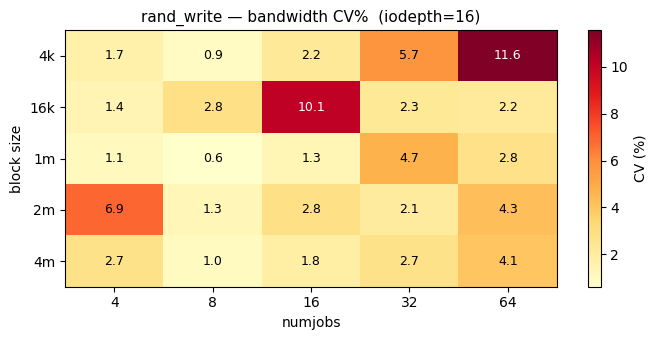

In [13]:
cv_pivot = (
    rw_summary.pivot(index="bs", columns="numjobs", values="bw_cv_pct")
    .reindex(BS_ORDER)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(cv_pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=ax, label="CV (%)")

ax.set_xticks(range(len(NJ_ORDER)))
ax.set_xticklabels(NJ_ORDER)
ax.set_yticks(range(len(BS_ORDER)))
ax.set_yticklabels(BS_ORDER)
ax.set_xlabel("numjobs")
ax.set_ylabel("block size")
ax.set_title("rand_write — bandwidth CV%  (iodepth=16)", fontsize=11)

for i, bs in enumerate(BS_ORDER):
    for j, nj in enumerate(NJ_ORDER):
        val = cv_pivot.loc[bs, nj]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9,
                    color="black" if val < cv_pivot.values[~np.isnan(cv_pivot.values)].max() * 0.6 else "white")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "randwrite_cv_pct_heatmap.pdf", bbox_inches="tight", dpi=150)
plt.show()

### Bandwidth by numjobs — median line + all runs as dots

Line = median across runs; dots = every individual run.  One color per `bs`.  x-axis log scale.

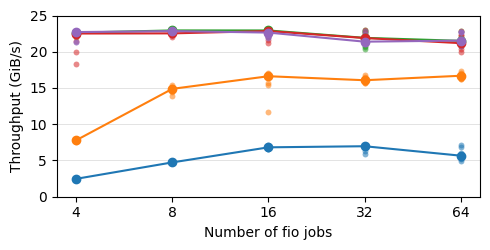

In [17]:
palette = sns.color_palette("tab10", n_colors=len(BS_ORDER))

rw_median = (
    rw_raw.groupby(["bs", "numjobs"], observed=True)["bw_GiBs"]
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 2.6))

for color, bs in zip(palette, BS_ORDER):
    med = rw_median[rw_median["bs"] == bs].set_index("numjobs").reindex(NJ_ORDER)
    ax.plot(NJ_ORDER, med["bw_GiBs"], color=color, marker="o", linewidth=1.5,
            markersize=6, zorder=3, label=bs)

    pts = rw_raw[rw_raw["bs"] == bs]
    ax.scatter(pts["numjobs"].astype(int), pts["bw_GiBs"], color=color, s=18,
               alpha=0.55, zorder=2, linewidths=0)

ax.set_xscale("log")
ax.set_xticks(NJ_ORDER)
ax.set_xticklabels(NJ_ORDER)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_ylim(0, 25)
ax.set_xlabel("Number of fio jobs")
ax.set_ylabel("Throughput (GiB/s)")
# ax.legend(title="Randwrite - fio I/O request size", ncol=len(BS_ORDER), loc="lower center",
        # bbox_to_anchor=(0.5, 1.0), framealpha=0.8, fontsize=8)
ax.grid(axis="y", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-randwrite_bw_median_by_nj.pdf", bbox_inches="tight", dpi=150)
plt.show()

In [15]:
med_pivot = (
    rw_raw.groupby(["bs", "numjobs"], observed=True)["bw_GiBs"]
    .median()
    .unstack("numjobs")
    .reindex(BS_ORDER)
    .round(3)
)
med_pivot.columns.name = "numjobs"
med_pivot.index.name   = "bs"
print("rand_write — median bandwidth (GiB/s)")
display(med_pivot)

rand_write — median bandwidth (GiB/s)


numjobs,4,8,16,32,64
bs,,,,,
4k,2.467,4.734,6.814,6.965,5.662
16k,7.786,14.881,16.622,16.070,16.688
1m,22.633,22.940,22.937,21.919,21.504
2m,22.514,22.534,22.852,21.893,21.185
4m,22.712,22.852,22.643,21.389,21.540
